## Load earthquake metadata and waveform data

Earthquake waveform records and their associated P-wave arrival annotations are loaded from the INSTANCE sample dataset. The metadata are used to identify the reference P-wave arrival sample for each waveform.

In [1]:
import numpy as np
import pandas as pd
import h5py
from pathlib import Path

project_root = Path.cwd().parent

metadata_path = (
    project_root
    / "data"
    / "sample"
    / "metadata"
    / "metadata_Instance_events_10k.csv"
)

hdf5_path = (
    project_root
    / "data"
    / "sample"
    / "data"
    / "Instance_events_counts_10k.hdf5"
)

metadata = pd.read_csv(metadata_path)

print("Metadata shape:", metadata.shape)

display(
    metadata[
        [
            "trace_name",
            "source_id",
            "trace_dt_s",
            "trace_P_arrival_sample",
            "trace_P_arrival_time"
        ]
    ].head()
)

Metadata shape: (10000, 115)


,trace_name,source_id,trace_dt_s,trace_P_arrival_sample,trace_P_arrival_time
0,11030611.IV.OFFI..HH,11030611,0.01,1735,2016-12-04T15:35:01.27Z
1,11030611.IV.PIEI..HH,11030611,0.01,1876,2016-12-04T15:35:06.90Z
2,11030611.IV.PIEI..HN,11030611,0.01,1889,2016-12-04T15:35:06.90Z
3,11030611.IV.RM33..EH,11030611,0.01,1678,2016-12-04T15:35:00.48Z
4,11030611.IV.RM33..HN,11030611,0.01,1610,2016-12-04T15:35:00.48Z


In [2]:
p_samples = metadata["trace_P_arrival_sample"]

print("Total records:", len(metadata))
print("Records with P arrival:", p_samples.notna().sum())
print("Records without P arrival:", p_samples.isna().sum())

print("\nP arrival sample statistics:")
print(p_samples.describe())

Total records: 10000
Records with P arrival: 10000
Records without P arrival: 0

P arrival sample statistics:
count    10000.000000
mean      2041.622800
std        628.404302
min       1457.000000
25%       1730.000000
50%       1885.500000
75%       2035.000000
max       6701.000000
Name: trace_P_arrival_sample, dtype: float64


## Inspect an annotated P-wave arrival

A representative earthquake waveform is loaded from the INSTANCE HDF5 file and plotted with its annotated P-wave arrival. The waveform sample index and corresponding arrival time are used as the reference for subsequent P-wave picking.

In [3]:
import matplotlib.pyplot as plt

trace_name = "11030611.IV.RM33..EH"

row = metadata[
    metadata["trace_name"] == trace_name
].iloc[0]

p_sample = int(row["trace_P_arrival_sample"])
dt = float(row["trace_dt_s"])

with h5py.File(hdf5_path, "r") as h5:

    waveform = np.array(
        h5[f"data/{trace_name}"]
    )

print("Waveform shape:", waveform.shape)
print("P arrival sample:", p_sample)
print("P arrival time:", p_sample * dt, "s")

Waveform shape: (3, 12000)
P arrival sample: 1678
P arrival time: 16.78 s


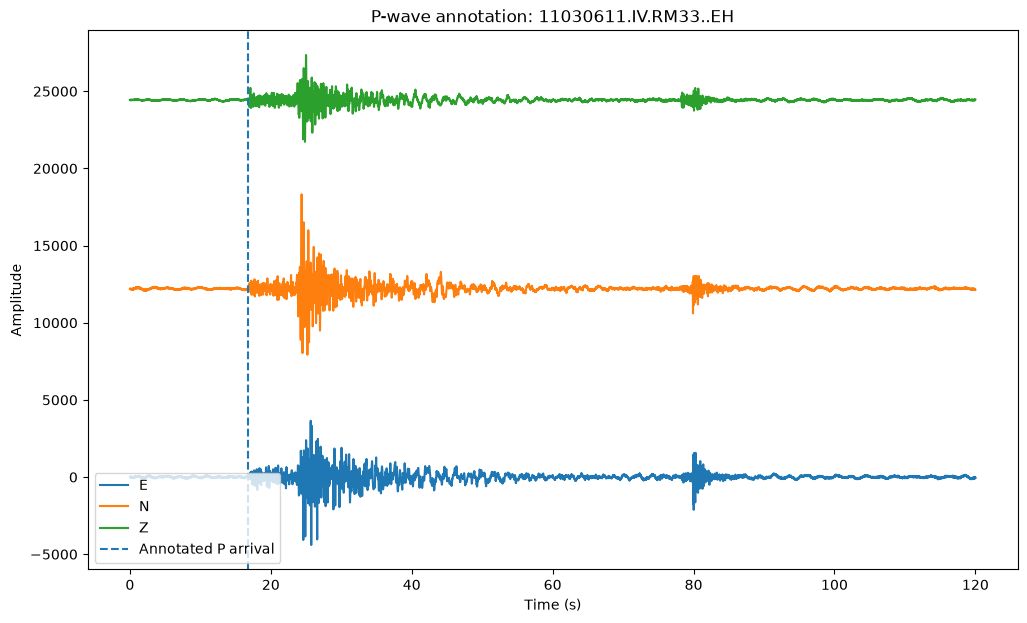

In [4]:
time = np.arange(waveform.shape[1]) * dt

component_names = ["E", "N", "Z"]

plt.figure(figsize=(12, 7))

for i, component in enumerate(component_names):

    plt.plot(
        time,
        waveform[i] + i * np.max(np.abs(waveform)) * 2,
        label=component
    )

plt.axvline(
    p_sample * dt,
    linestyle="--",
    label="Annotated P arrival"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"P-wave annotation: {trace_name}")
plt.legend()
plt.show()

## Traditional P-wave picking using STA/LTA

The STA/LTA characteristic function is used to identify transient waveform onsets associated with the P-wave. The first valid trigger is treated as the estimated P-wave arrival and is compared with the annotated INSTANCE arrival.

In [5]:
from scipy.signal import butter, sosfiltfilt
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# Use Z component
z = waveform[2].astype(np.float64)

# Constant detrend
z = z - np.mean(z)

# 3–20 Hz bandpass filter
fs = 1.0 / dt

sos = butter(
    4,
    [3.0, 20.0],
    btype="bandpass",
    fs=fs,
    output="sos"
)

z_filtered = sosfiltfilt(sos, z)

# STA/LTA
nsta = int(1.0 * fs)
nlta = int(10.0 * fs)

characteristic = classic_sta_lta(
    z_filtered,
    nsta,
    nlta
)

triggers = trigger_onset(
    characteristic,
    3.0,
    1.5
)

print("Detected triggers:")
print(triggers)

print("\nAnnotated P sample:", p_sample)
print("Annotated P time:", p_sample * dt, "s")

Detected triggers:
[[1668 2213]
 [2413 2728]
 [7830 8183]]

Annotated P sample: 1678
Annotated P time: 16.78 s


## STA/LTA characteristic function

The STA/LTA characteristic function and detected trigger intervals are plotted alongside the annotated P-wave arrival to assess the behavior of the traditional picker.

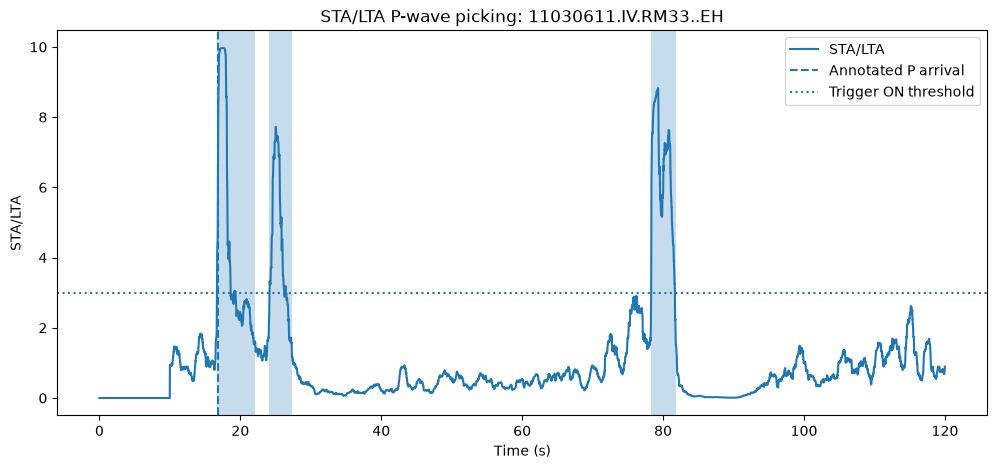

In [6]:
time = np.arange(len(z_filtered)) * dt

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    characteristic,
    label="STA/LTA"
)

plt.axvline(
    p_sample * dt,
    linestyle="--",
    label="Annotated P arrival"
)

for start, end in triggers:
    plt.axvspan(
        start / fs,
        end / fs,
        alpha=0.25
    )

plt.axhline(
    3.0,
    linestyle=":",
    label="Trigger ON threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("STA/LTA")
plt.title(f"STA/LTA P-wave picking: {trace_name}")
plt.legend()
plt.show()

In [7]:
if len(triggers) > 0:

    predicted_p_sample = int(triggers[0, 0])

    predicted_p_time = predicted_p_sample * dt
    annotated_p_time = p_sample * dt

    picking_error = abs(
        predicted_p_time - annotated_p_time
    )

    print(f"Predicted P arrival: {predicted_p_time:.2f} s")
    print(f"Annotated P arrival: {annotated_p_time:.2f} s")
    print(f"Absolute picking error: {picking_error:.2f} s")

else:
    print("No STA/LTA trigger detected.")

Predicted P arrival: 16.68 s
Annotated P arrival: 16.78 s
Absolute picking error: 0.10 s


## Full-dataset STA/LTA P-wave picking

The traditional STA/LTA picker is applied to all 10,000 earthquake recordings in the INSTANCE sample dataset. For each waveform, the Z component is selected for P-wave onset detection. The waveform is first converted to floating-point representation and constant detrending is applied to remove the mean value. A fourth-order zero-phase Butterworth bandpass filter with a frequency range of 3–20 Hz is then applied to suppress low-frequency trends and higher-frequency noise.

The filtered waveform is processed using a 1 s short-term average and a 10 s long-term average at the 100 Hz sampling rate. Trigger intervals are identified using an ON threshold of 3.0 and an OFF threshold of 1.5. The onset of the first detected trigger is treated as the estimated P-wave arrival.

The annotated P-wave arrival sample provided in the INSTANCE metadata is used only as the reference for evaluating picking accuracy. It is not used to constrain the STA/LTA search or determine the predicted arrival.

In [9]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset
from scipy.signal import butter, sosfiltfilt

fs = 100.0
dt = 1.0 / fs

nsta = int(1.0 * fs)
nlta = int(10.0 * fs)

threshold_on = 3.0
threshold_off = 1.5


results = []

with h5py.File(hdf5_path, "r") as h5:

    for _, row in metadata.iterrows():

        trace_name = row["trace_name"]
        annotated_p_sample = int(
            row["trace_P_arrival_sample"]
        )

        # Load waveform
        waveform = np.array(
            h5[f"data/{trace_name}"]
        )

        # Use Z component
        z = waveform[2].astype(np.float64)

        # Constant detrend
        z = z - np.mean(z)

        # 3–20 Hz bandpass
        sos = butter(
            4,
            [3.0, 20.0],
            btype="bandpass",
            fs=fs,
            output="sos"
        )

        z_filtered = sosfiltfilt(
            sos,
            z
        )

        # STA/LTA
        characteristic = classic_sta_lta(
            z_filtered,
            nsta,
            nlta
        )

        triggers = trigger_onset(
            characteristic,
            threshold_on,
            threshold_off
        )

        if len(triggers) > 0:

            predicted_p_sample = int(
                triggers[0, 0]
            )

            predicted_p_time = (
                predicted_p_sample * dt
            )

            annotated_p_time = (
                annotated_p_sample * dt
            )

            error = abs(
                predicted_p_time -
                annotated_p_time
            )

            detected = True

        else:

            predicted_p_sample = np.nan
            predicted_p_time = np.nan
            error = np.nan
            detected = False

        results.append({
            "trace_name": trace_name,
            "source_id": row["source_id"],
            "annotated_p_sample": annotated_p_sample,
            "annotated_p_time_s":
                annotated_p_sample * dt,
            "predicted_p_sample":
                predicted_p_sample,
            "predicted_p_time_s":
                predicted_p_time,
            "absolute_error_s":
                error,
            "detected": detected
        })


stage2_sta_lta_results = pd.DataFrame(results)

print(
    "Total recordings:",
    len(stage2_sta_lta_results)
)

print(
    "Successful picks:",
    stage2_sta_lta_results["detected"].sum()
)

print(
    "Missed picks:",
    (~stage2_sta_lta_results["detected"]).sum()
)

Total recordings: 10000
Successful picks: 9808
Missed picks: 192


## STA/LTA picking performance

The distribution of absolute P-wave picking errors is summarized using the mean and median error. The proportion of recordings for which a STA/LTA trigger was obtained is also reported.

In [10]:
successful_picks = stage2_sta_lta_results[
    stage2_sta_lta_results["detected"]
]

mean_error = successful_picks[
    "absolute_error_s"
].mean()

median_error = successful_picks[
    "absolute_error_s"
].median()

success_rate = (
    len(successful_picks) /
    len(stage2_sta_lta_results)
)

print(f"Successful picks: {len(successful_picks)}")
print(
    f"Missed picks: "
    f"{len(stage2_sta_lta_results) - len(successful_picks)}"
)
print(f"Pick success rate: {success_rate:.4f}")
print(f"Mean absolute error: {mean_error:.4f} s")
print(f"Median absolute error: {median_error:.4f} s")

Successful picks: 9808
Missed picks: 192
Pick success rate: 0.9808
Mean absolute error: 2.7246 s
Median absolute error: 0.2500 s


In [11]:
results_path = (
    project_root
    / "results"
    / "metrics"
    / "stage2_sta_lta_picking.csv"
)

stage2_sta_lta_results.to_csv(
    results_path,
    index=False
)

print("Saved:", results_path)

Saved: /home/yashwik/earth-science-projects/earthquake-detection-ml/results/metrics/stage2_sta_lta_picking.csv


## STA/LTA picking-error distribution

The distribution of absolute P-wave picking errors is examined to characterize both typical picking accuracy and large-error outliers. The proportion of successful picks falling within selected timing tolerances is also calculated.

In [12]:
successful_errors = (
    stage2_sta_lta_results
    .loc[
        stage2_sta_lta_results["detected"],
        "absolute_error_s"
    ]
)

print("Within 0.1 s:",
      (successful_errors <= 0.1).mean())

print("Within 0.5 s:",
      (successful_errors <= 0.5).mean())

print("Within 1.0 s:",
      (successful_errors <= 1.0).mean())

print("Within 2.0 s:",
      (successful_errors <= 2.0).mean())

print("90th percentile error:",
      successful_errors.quantile(0.90))

print("95th percentile error:",
      successful_errors.quantile(0.95))

print("99th percentile error:",
      successful_errors.quantile(0.99))

Within 0.1 s: 0.3078099510603589
Within 0.5 s: 0.6341761827079935
Within 1.0 s: 0.7214518760195758
Within 2.0 s: 0.7641721044045677
90th percentile error: 8.013000000000012
95th percentile error: 12.036499999999997
99th percentile error: 31.32790000000001


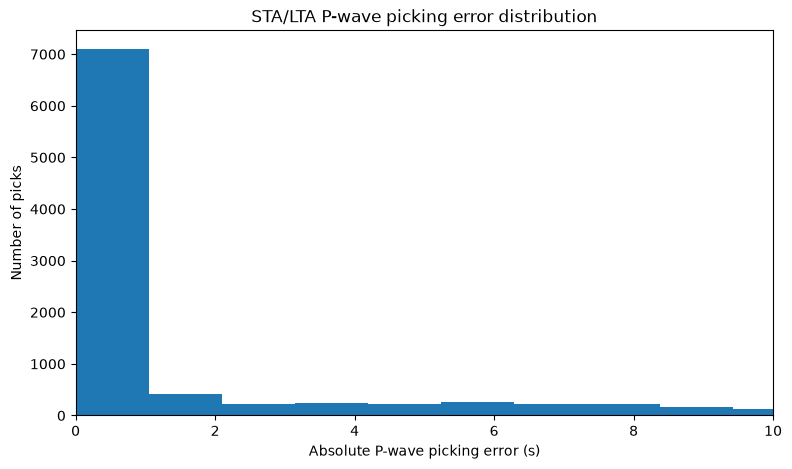

In [13]:
plt.figure(figsize=(9, 5))

plt.hist(
    successful_errors,
    bins=100
)

plt.xlabel("Absolute P-wave picking error (s)")
plt.ylabel("Number of picks")
plt.title("STA/LTA P-wave picking error distribution")
plt.xlim(0, min(successful_errors.max(), 10))

plt.show()

## Analysis of large P-wave picking errors

Recordings with the largest STA/LTA picking errors are identified to investigate the causes of substantial deviations from the annotated P-wave arrivals.

In [14]:
worst_picks = (
    stage2_sta_lta_results[
        stage2_sta_lta_results["detected"]
    ]
    .sort_values(
        "absolute_error_s",
        ascending=False
    )
    .head(10)
)

display(
    worst_picks[
        [
            "trace_name",
            "source_id",
            "annotated_p_time_s",
            "predicted_p_time_s",
            "absolute_error_s"
        ]
    ]
)

,trace_name,source_id,annotated_p_time_s,predicted_p_time_s,absolute_error_s
8447,11256591.IV.MPAG..HN,11256591,15.26,119.93,104.67
159,11032751.IV.MPAG..HN,11032751,15.90,119.64,103.74
2130,11085571.IV.MPAG..HN,11085571,16.60,119.96,103.36
5547,11176991.IV.MPAG..HN,11176991,16.82,119.83,103.01
6221,11190061.IV.T1299..HN,11190061,17.07,119.93,102.86
4361,11148041.IV.MPAG..HN,11148041,17.12,119.76,102.64
7597,11236231.IV.MPAG..HN,11236231,17.37,119.92,102.55
3163,11117901.IV.SACS..HN,11117901,17.68,119.98,102.30
286,1103391.IV.NRCA..HN,1103391,17.69,119.95,102.26
4988,11172651.IV.MPAG..HN,11172651,17.64,119.76,102.12


In [15]:
worst_trace = worst_picks.iloc[0]

print("Trace:", worst_trace["trace_name"])
print(
    "Annotated P:",
    worst_trace["annotated_p_time_s"],
    "s"
)
print(
    "STA/LTA P:",
    worst_trace["predicted_p_time_s"],
    "s"
)
print(
    "Error:",
    worst_trace["absolute_error_s"],
    "s"
)

Trace: 11256591.IV.MPAG..HN
Annotated P: 15.26 s
STA/LTA P: 119.93 s
Error: 104.67 s


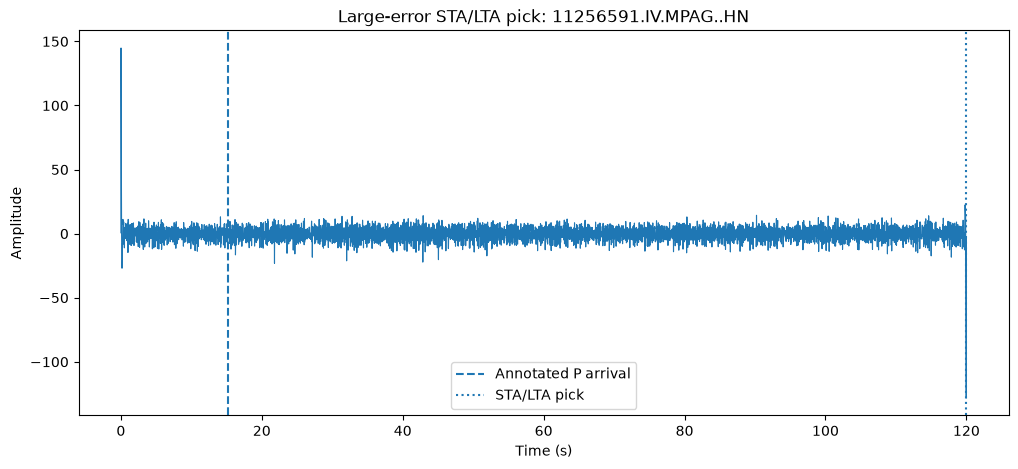

In [16]:
trace_name = worst_trace["trace_name"]

row = metadata[
    metadata["trace_name"] == trace_name
].iloc[0]

p_sample = int(row["trace_P_arrival_sample"])

with h5py.File(hdf5_path, "r") as h5:
    waveform = np.array(
        h5[f"data/{trace_name}"]
    )

z = waveform[2].astype(np.float64)
z = z - np.mean(z)

z_filtered = sosfiltfilt(
    sos,
    z
)

time = np.arange(len(z_filtered)) / fs

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    z_filtered,
    linewidth=0.8
)

plt.axvline(
    p_sample / fs,
    linestyle="--",
    label="Annotated P arrival"
)

plt.axvline(
    worst_trace["predicted_p_time_s"],
    linestyle=":",
    label="STA/LTA pick"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Large-error STA/LTA pick: {trace_name}")
plt.legend()
plt.show()